In [1]:
#install.packages('caret') # split train-test data
#install.packages('PRROC') # precision-recall curve
#install.packages('Metrics') #Fbeta score
#install.packages("randomForest")
#install.packages('mdatools') # PLS-DA
#install.packages("LiblineaR")
#install.packages('e1071') 

In [2]:
library(tidyverse)

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
data <- read.csv("cardiovascular_disease_data.csv")
head(data)
summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

In [4]:
data$Gender = as.factor(data$Gender)
data$Smoking_Status = as.factor(data$Smoking_Status)
data$Alcohol_Consumption = as.factor(data$Alcohol_Consumption)
data$Physical_Activity_Level = as.factor(data$Physical_Activity_Level)
data$Family_History = as.factor(data$Family_History)
data$Stress_Level = as.factor(data$Stress_Level)
data$Sleep_Hours = as.factor(data$Sleep_Hours)
data$Heart_Disease_Risk = as.factor(data$Heart_Disease_Risk)

In [5]:
# change patient ID to index

data = data %>% column_to_rownames(., var="Patient_ID")

In [6]:
summary(data)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
                                                                          
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:

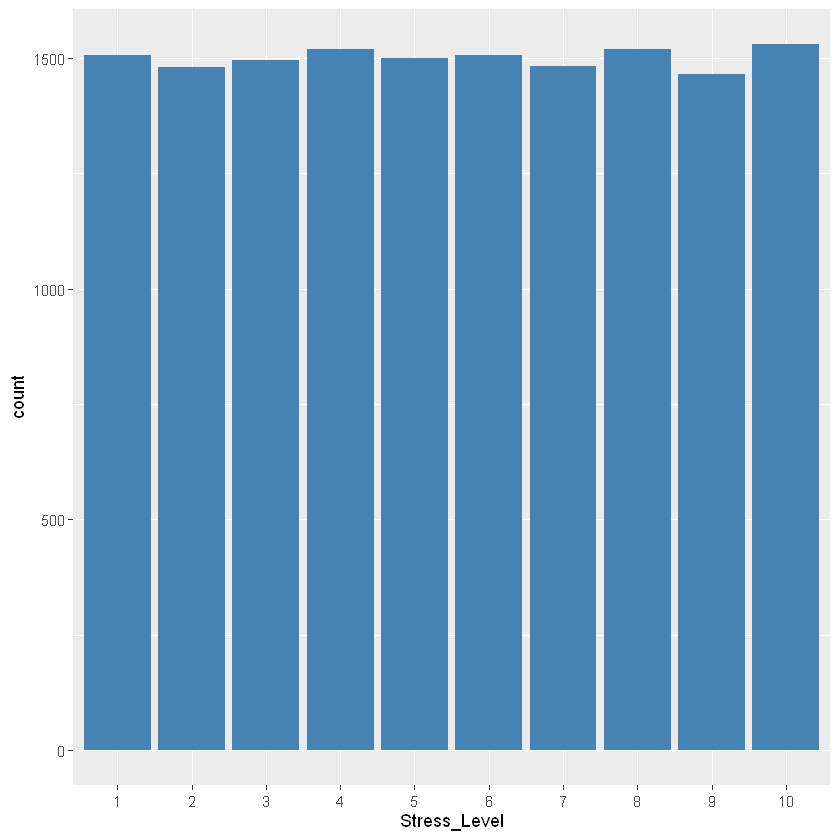

In [7]:
ggplot(data = data, aes(x=Stress_Level)) + geom_bar(stat = 'count', fill="steelblue")

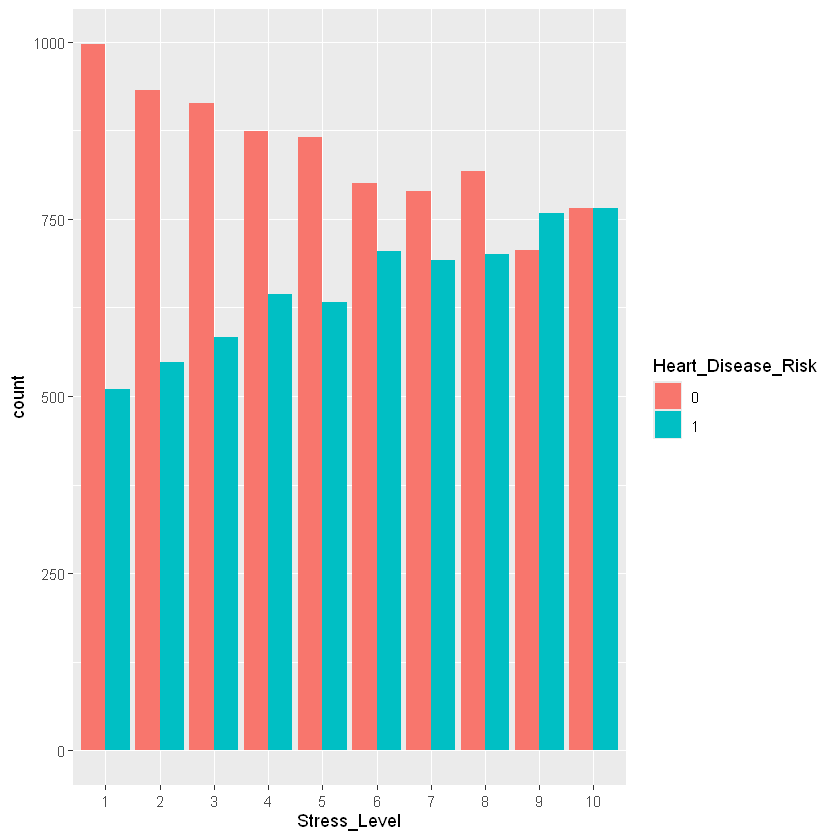

In [8]:
ggplot(data = data, aes(x=Stress_Level, fill=Heart_Disease_Risk))+ geom_bar(stat = 'count', position=position_dodge())

In [9]:
data$Stress_Level = as.numeric(data$Stress_Level)

**Comment** Lineear relation, so treating stress_level as quantitative still works

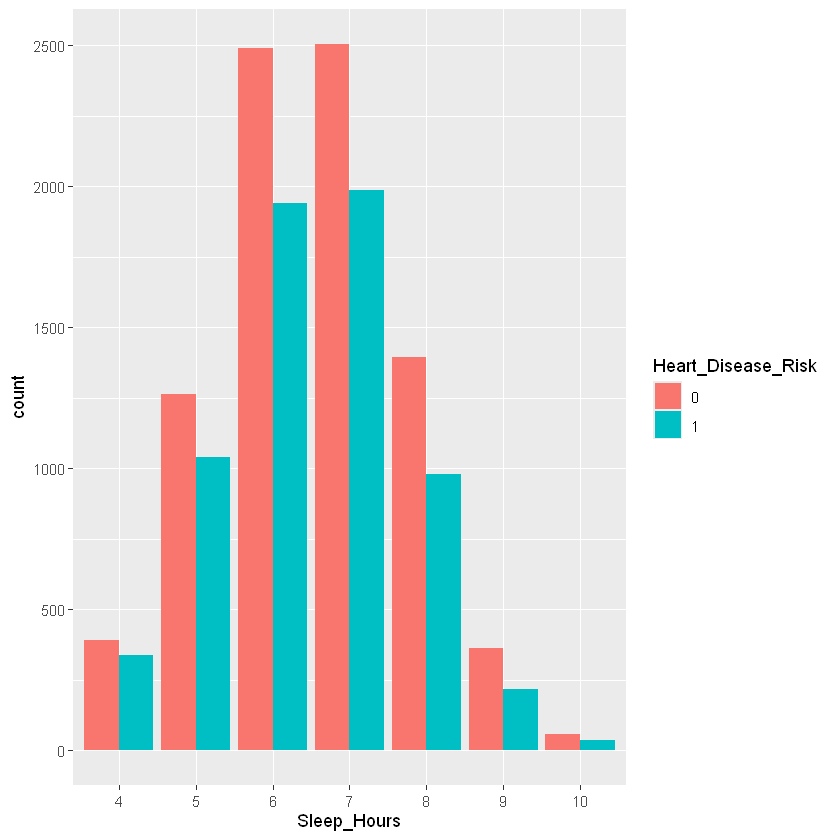

In [10]:
ggplot(data = data, aes(x=Sleep_Hours, fill=Heart_Disease_Risk))+ geom_bar(stat = 'count', position=position_dodge())

# Prepare data

In [11]:
# list of quantitative variable

numeric_cols <- names(data)[sapply(data, is.numeric)]
numeric_cols

[1] "Age"                 "Height_cm"           "Weight_kg"          
 [4] "BMI"                 "Systolic_BP"         "Diastolic_BP"       
 [7] "Cholesterol_Total"   "Cholesterol_LDL"     "Cholesterol_HDL"    
[10] "Fasting_Blood_Sugar" "Stress_Level"

In [12]:
# List of qualitative variables

categorical_cols <- names(data)[sapply(data, is.factor)]
categorical_cols

[1] "Gender"                  "Smoking_Status"         
[3] "Alcohol_Consumption"     "Physical_Activity_Level"
[5] "Family_History"          "Sleep_Hours"            
[7] "Heart_Disease_Risk"

**Important!!!**

We will use the function $\textit{createDataPartition}$ in the package $\textit{caret}$ to create the train data and test data. Before doing any analysis, we need to rescale the qualitative variables, since they have different scales.

In [13]:
library(caret)

Warning message:
"package 'caret' was built under R version 4.4.3"
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift




In [14]:
#help(createDataPartition)

In [15]:
set.seed(111)
### Create dataset for Heart disease risk
train_id_H <- createDataPartition(data$Heart_Disease_Risk, p = 0.8, list = FALSE)
trainH <- data[train_id_H, ]
testH  <- data[-train_id_H, ]

# estimate scaling on training only
preproc <- preProcess(trainH[, numeric_cols], method = c("center", "scale"))

#apply the center and scale on the train and test data
train_scaledH <- predict(preproc, trainH)
test_scaledH  <- predict(preproc, testH)

In [16]:
dim(train_scaledH)
dim(test_scaledH)

[1] 12000    18

[1] 3000   18

In [17]:
summary(train_scaledH)
summary(test_scaledH)

      Age          Gender     Height_cm          Weight_kg      
 Min.   :-2.4949   0:6085   Min.   :-2.92900   Min.   :-2.6069  
 1st Qu.:-0.7210   1:5915   1st Qu.:-0.74765   1st Qu.:-0.7106  
 Median : 0.0392            Median :-0.06053   Median :-0.1020  
 Mean   : 0.0000            Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.7150            3rd Qu.: 0.73566   3rd Qu.: 0.6127  
 Max.   : 2.5733            Max.   : 3.53869   Max.   : 5.2970  
                                                                
      BMI            Systolic_BP         Diastolic_BP      Cholesterol_Total 
 Min.   :-3.12711   Min.   :-3.993653   Min.   :-3.60776   Min.   :-3.94837  
 1st Qu.:-0.70976   1st Qu.:-0.716731   1st Qu.:-0.65306   1st Qu.:-0.67555  
 Median :-0.05708   Median :-0.008207   Median : 0.05607   Median :-0.01214  
 Mean   : 0.00000   Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.61978   3rd Qu.: 0.700317   3rd Qu.: 0.64701   3rd Qu.: 0.65127  
 Max.   : 4.

      Age             Gender     Height_cm           Weight_kg        
 Min.   :-2.4948786   0:1537   Min.   :-2.928998   Min.   :-2.939519  
 1st Qu.:-0.6576710   1:1463   1st Qu.:-0.758559   1st Qu.:-0.710566  
 Median :-0.0452685            Median :-0.087796   Median :-0.063108  
 Mean   : 0.0009362            Mean   :-0.009925   Mean   : 0.003791  
 3rd Qu.: 0.7149553            3rd Qu.: 0.713849   3rd Qu.: 0.640958  
 Max.   : 2.5732803            Max.   : 3.571411   Max.   : 3.782720  
                                                                      
      BMI            Systolic_BP         Diastolic_BP       Cholesterol_Total 
 Min.   :-2.93372   Min.   :-3.550826   Min.   :-3.607762   Min.   :-3.19651  
 1st Qu.:-0.68559   1st Qu.:-0.628165   1st Qu.:-0.653058   1st Qu.:-0.71978  
 Median :-0.05708   Median :-0.008207   Median : 0.056070   Median :-0.01214  
 Mean   : 0.01203   Mean   : 0.011071   Mean   : 0.009268   Mean   :-0.00586  
 3rd Qu.: 0.61978   3rd Qu.: 0.611751

# Heart disease risk

In order to compare the efficiency of each method, we need to find an indicator. For python the default score is the accuracy, i.e. (True pos + True neg)/total samples. However if we want to minimize the risk of saying a patient is healthy while he/she has a heart disease, we need to minimize false negative rate, i.e. maximize sensitivity (True pos / total real pos).

## Logistic regression

In [18]:
res.log = glm(Heart_Disease_Risk~., family="binomial", data=train_scaledH)

In [19]:
summary(res.log)


Call:
glm(formula = Heart_Disease_Risk ~ ., family = "binomial", data = train_scaledH)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.167214   0.113769  -1.470  0.14162    
Age                       0.238227   0.026439   9.010  < 2e-16 ***
Gender1                  -0.077936   0.065133  -1.197  0.23148    
Height_cm                -0.114970   0.145361  -0.791  0.42899    
Weight_kg                 0.242453   0.237844   1.019  0.30802    
BMI                       0.001155   0.192751   0.006  0.99522    
Systolic_BP               0.340025   0.038523   8.826  < 2e-16 ***
Diastolic_BP             -0.008856   0.036748  -0.241  0.80957    
Cholesterol_Total        -0.046646   0.040699  -1.146  0.25175    
Cholesterol_LDL           0.208707   0.039065   5.343 9.16e-08 ***
Cholesterol_HDL          -0.057620   0.026062  -2.211  0.02704 *  
Fasting_Blood_Sugar       0.328689   0.022883  14.364  < 2e-16 ***
Smoking_Status1           

**Comment** : We can observe the significance of the parameters. It seems that the risk of having heart disease depends on Age, Systolic BP, Cholesterol_LDL, Fasting blood sugar, Smoking status, Physical activity level, Family history, Stress level and Sleep hours. This result is coherent with the exploratory analysis.

In [20]:
library(PRROC)
library(Metrics)

Warning message:
"package 'PRROC' was built under R version 4.4.3"
Loading required package: rlang


Attaching package: 'rlang'


The following objects are masked from 'package:purrr':

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice


Warning message:
"package 'Metrics' was built under R version 4.4.3"

Attaching package: 'Metrics'


The following object is masked from 'package:rlang':

    ll


The following objects are masked from 'package:caret':

    precision, recall




       
           0    1
  FALSE 1398  491
  TRUE   294  817

[1] 0.6246177

[1] 0.7353735

[1] 0.6754857

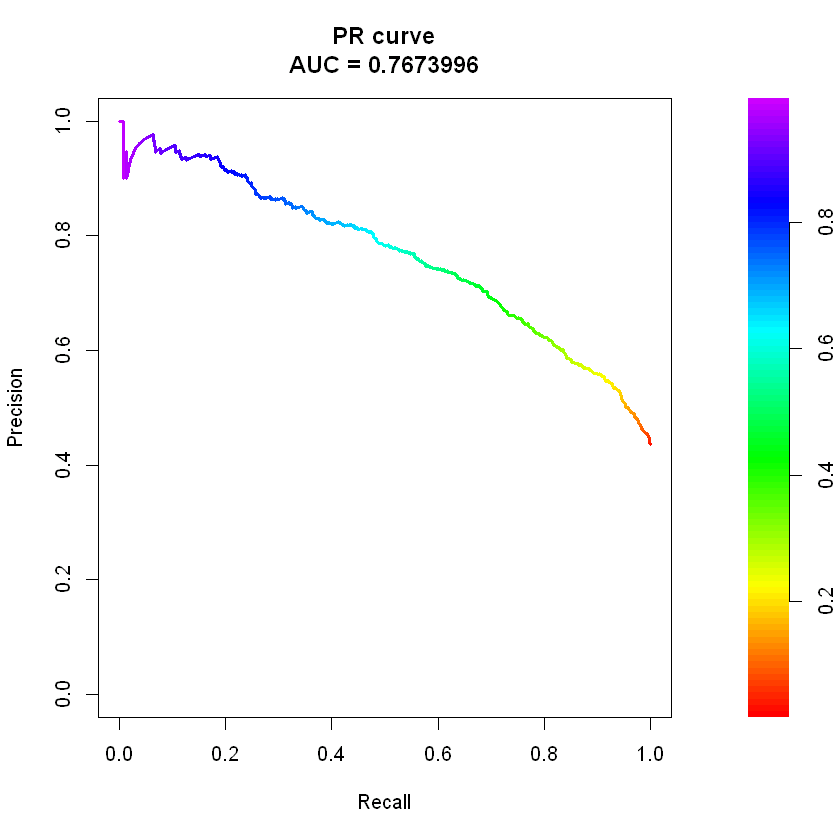

In [21]:
pred.log <- predict(res.log, newdata = test_scaledH, type = "response")
table(pred.log > 0.5, test_scaledH[, "Heart_Disease_Risk"])

#Recall
sum(pred.log >0.5 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.log >0.5 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.log >0.5)

#Fb score
y_true <- as.numeric(as.character(test_scaledH[, "Heart_Disease_Risk"]))
fbeta_score(y_true, pred.log >0.5, beta = 1)

#Plot the precision recall curve

plot(pr.curve(
  scores.class0 = pred.log,
  weights.class0 = y_true,
  curve = TRUE
))

In [22]:
score = c()
for (x in seq(0.1, 0.7, length.out = 50)){
    score = c(score,fbeta_score(y_true, pred.log >x, beta = 1))
    print(c(x,fbeta_score(y_true, pred.log >x, beta = 1)))
}

[1] 0.1000000 0.6333415
[1] 0.1122449 0.6387016
[1] 0.1244898 0.6455375
[1] 0.1367347 0.6510671
[1] 0.1489796 0.6558577
[1] 0.1612245 0.6618896
[1] 0.1734694 0.6666667
[1] 0.1857143 0.6750478
[1] 0.1979592 0.6804009
[1] 0.2102041 0.6847918
[1] 0.2224490 0.6885435
[1] 0.2346939 0.6901202
[1] 0.2469388 0.6915944
[1] 0.2591837 0.6915089
[1] 0.2714286 0.6901670
[1] 0.2836735 0.6948831
[1] 0.2959184 0.6984635
[1] 0.3081633 0.6987013
[1] 0.3204082 0.7013500
[1] 0.3326531 0.7009689
[1] 0.3448980 0.7007794
[1] 0.3571429 0.7015491
[1] 0.3693878 0.7003155
[1] 0.3816327 0.7015670
[1] 0.3938776 0.6968162
[1] 0.4061224 0.6959707
[1] 0.4183673 0.6981764
[1] 0.4306122 0.6970954
[1] 0.4428571 0.6947530
[1] 0.4551020 0.6945312
[1] 0.4673469 0.6901743
[1] 0.4795918 0.6822769
[1] 0.4918367 0.6792608
[1] 0.5040816 0.6741294
[1] 0.5163265 0.6691824
[1] 0.5285714 0.6615776
[1] 0.5408163 0.6514236
[1] 0.5530612 0.6468271
[1] 0.5653061 0.6439024
[1] 0.5775510 0.6339044
[1] 0.5897959 0.6258566
[1] 0.6020408 0.

In [23]:
seq(0.1, 0.7, length.out = 50)[which.max(score)]

[1] 0.3816327

In [24]:
p=seq(0.1, 0.7, length.out = 50)[which.max(score)]
#Recall
sum(pred.log >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.log >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.log >p)

table(pred.log > p, test_scaledH[, "Heart_Disease_Risk"])

[1] 0.7530581

[1] 0.6566667

       
           0    1
  FALSE 1177  323
  TRUE   515  985

### Logistic regression - AIC

In [25]:
#help(step)

In [26]:
res.log.aic = step(res.log, direction='backward')

Start:  AIC=12669.82
Heart_Disease_Risk ~ Age + Gender + Height_cm + Weight_kg + BMI + 
    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
    Cholesterol_HDL + Fasting_Blood_Sugar + Smoking_Status + 
    Alcohol_Consumption + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours

                          Df Deviance   AIC
- BMI                      1    12618 12668
- Diastolic_BP             1    12618 12668
- Alcohol_Consumption      2    12620 12668
- Height_cm                1    12618 12668
- Weight_kg                1    12619 12669
- Cholesterol_Total        1    12619 12669
- Gender                   1    12619 12669
<none>                          12618 12670
- Cholesterol_HDL          1    12623 12673
- Sleep_Hours              6    12639 12679
- Cholesterol_LDL          1    12646 12696
- Systolic_BP              1    12696 12746
- Age                      1    12700 12750
- Stress_Level             1    12796 12846
- Fasting_Blood_

       
           0    1
  FALSE 1398  490
  TRUE   294  818

[1] 0.6253823

[1] 0.7356115

[1] 0.6760331

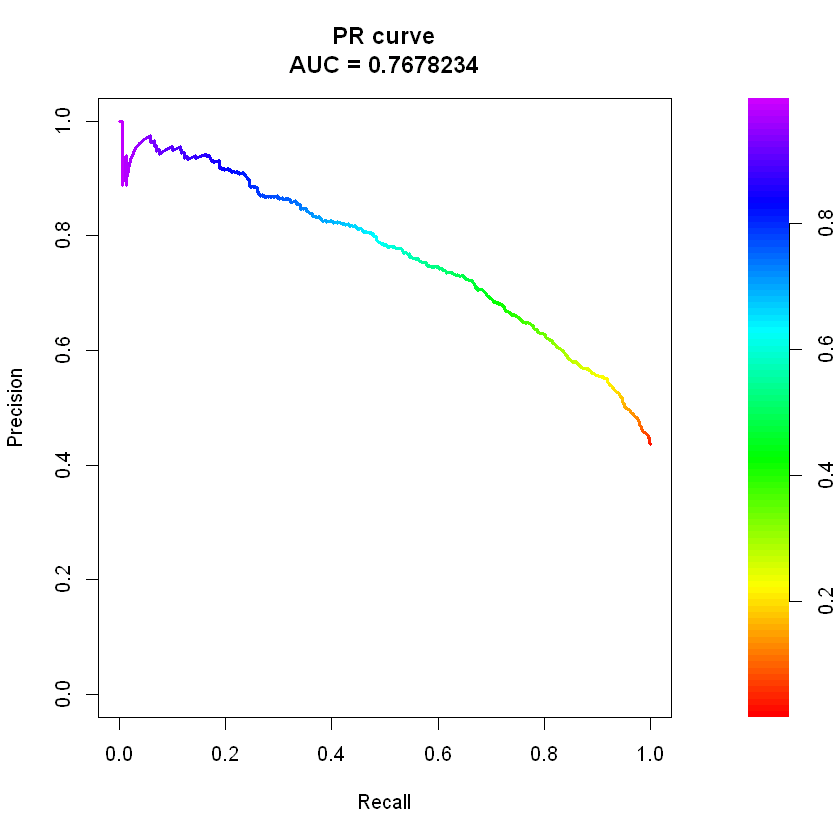

In [27]:
pred.log.aic <- predict(res.log.aic, newdata = test_scaledH, type = "response")
# Matrice de confusion pour la prévision du 
# dépassement de seuil
table(pred.log.aic > 0.5, test_scaledH[, "Heart_Disease_Risk"])

#Recall
sum(pred.log.aic >0.5 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.log.aic >0.5 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.log.aic >0.5)

#F beta score
fbeta_score(y_true, pred.log.aic >0.5, beta = 1)

plot(pr.curve(
  scores.class0 = pred.log.aic,
  weights.class0 = y_true,
  curve = TRUE
))

In [28]:
p=0.1
score = 0
for (x in seq(0.1, 0.7, length.out = 50)){
    if (score < fbeta_score(y_true, pred.log.aic >x, beta = 1)){
        p = x
        score = fbeta_score(y_true, pred.log.aic >x, beta = 1)
    }
}
p
#Recall
sum(pred.log.aic >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.log.aic >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.log >p)

table(pred.log.aic > p, test_scaledH[, "Heart_Disease_Risk"])

[1] 0.3693878

[1] 0.7675841

[1] 0.6498382

       
           0    1
  FALSE 1149  304
  TRUE   543 1004

In [29]:
summary(res.log.aic)


Call:
glm(formula = Heart_Disease_Risk ~ Age + Height_cm + Weight_kg + 
    Systolic_BP + Cholesterol_LDL + Cholesterol_HDL + Fasting_Blood_Sugar + 
    Smoking_Status + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours, family = "binomial", data = train_scaledH)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.22975    0.10775  -2.132  0.03298 *  
Age                       0.23055    0.02565   8.989  < 2e-16 ***
Height_cm                -0.13914    0.02757  -5.048 4.47e-07 ***
Weight_kg                 0.24324    0.03040   8.002 1.23e-15 ***
Systolic_BP               0.33355    0.02478  13.459  < 2e-16 ***
Cholesterol_LDL           0.17316    0.02379   7.278 3.38e-13 ***
Cholesterol_HDL          -0.04713    0.02455  -1.919  0.05494 .  
Fasting_Blood_Sugar       0.32849    0.02287  14.362  < 2e-16 ***
Smoking_Status1           1.97834    0.04994  39.613  < 2e-16 ***
Physical_Activity_Level1 -0.58510  

In [30]:
anova(res.log.aic, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16438.38,NA
Age,1,341.4117701,11998,16096.97,3.143504e-76
Height_cm,1,0.4077415,11997,16096.56,5.231180e-01
Weight_kg,1,215.7135281,11996,15880.85,7.787776e-49
Systolic_BP,1,158.6956416,11995,15722.16,2.180931e-36
Cholesterol_LDL,1,43.1503646,11994,15679.00,5.069045e-11
Cholesterol_HDL,1,3.0627434,11993,15675.94,8.010631e-02
Fasting_Blood_Sugar,1,173.2186608,11992,15502.72,1.466278e-39
Smoking_Status,1,1640.2029765,11991,13862.52,0.000000e+00


In [31]:
# Test of sub model : verify if the submodel is efficient enough

anova(res.log.aic, res.log, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,11980,12622.73,NA,NA,NA
2,11974,12617.82,6,4.914197,0.5548642


**Comment:** According to the submodel test, we conclude that we can replace the complete model by submodel.

In [32]:
# Odd ratio
as.table(exp(res.log.aic$coefficients))

             (Intercept)                      Age                Height_cm 
               0.7947297                1.2592933                0.8701036 
               Weight_kg              Systolic_BP          Cholesterol_LDL 
               1.2753799                1.3959173                1.1890552 
         Cholesterol_HDL      Fasting_Blood_Sugar          Smoking_Status1 
               0.9539669                1.3888697                7.2307199 
Physical_Activity_Level1 Physical_Activity_Level2 Physical_Activity_Level3 
               0.5570516                0.3281871                0.2083265 
         Family_History1             Stress_Level             Sleep_Hours5 
               4.3793332                1.3381101                0.9684577 
            Sleep_Hours6             Sleep_Hours7             Sleep_Hours8 
               0.8153382                0.8144013                0.7629508 
            Sleep_Hours9            Sleep_Hours10 
               0.6132719             

**Comments:**
- A smoking person can have about 7 times higher risk of having cardiovascular diseases compared to non-smoking person.
- For a person which family history had a heart disease patient, the odds of having the disease is about 4 times higher than those not having any in the family history.
- The stress level increases the risk, while the sleep hour reduces it.
- ...

In [33]:
library(ROCR)

Warning message:
"package 'ROCR' was built under R version 4.4.3"


In [34]:
roclogit <- predict(res.log.aic, newdata = test_scaledH, type="response")
predlogit <- prediction(roclogit, test_scaledH[, "Heart_Disease_Risk"])
perflogit <- performance(predlogit, "tpr", "fpr")

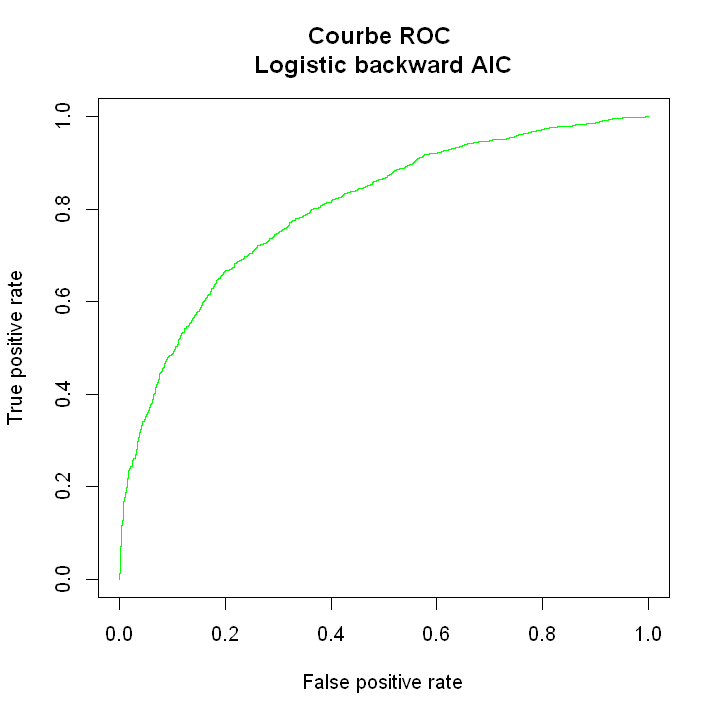

In [35]:
options(repr.plot.width = 6, repr.plot.height = 6)
plot(perflogit,col="green",lty=1, main = "Courbe ROC \n Logistic backward AIC ") 

## LDA

In [36]:
library(glmnet)
library(MASS)

Warning message:
"package 'glmnet' was built under R version 4.4.3"
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10

Warning message:
"package 'MASS' was built under R version 4.4.3"

Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select




In [37]:
res.lda <- lda(Heart_Disease_Risk~., data=train_scaledH)
res.lda

Call:
lda(Heart_Disease_Risk ~ ., data = train_scaledH)

Prior probabilities of groups:
    0     1 
0.564 0.436 

Group means:
         Age   Gender1    Height_cm   Weight_kg        BMI Systolic_BP
0 -0.1473106 0.4946809 -0.004046744 -0.09820723 -0.1186026  -0.1701976
1  0.1905578 0.4906346  0.005234779  0.12703871  0.1534217   0.2201639
  Diastolic_BP Cholesterol_Total Cholesterol_LDL Cholesterol_HDL
0   -0.1355837        -0.1189381      -0.1184874      0.05416145
1    0.1753880         0.1538557       0.1532726     -0.07006205
  Fasting_Blood_Sugar Smoking_Status1 Alcohol_Consumption1 Alcohol_Consumption2
0          -0.1452366       0.1619385            0.4026300            0.1022459
1           0.1878749       0.4894878            0.3881881            0.1041667
  Physical_Activity_Level1 Physical_Activity_Level2 Physical_Activity_Level3
0                0.3863771                0.3345154               0.12470449
1                0.4241208                0.2450306               0.06

In [38]:
pred.lda <- predict(res.lda, test_scaledH)
table(pred.lda$class, test_scaledH[, "Heart_Disease_Risk"])

# Recall
sum(pred.lda$class == 1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.lda$class == 1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.lda$class == 1)

#F beta score
fbeta_score(y_true, pred.lda$class ==1, beta = 2)

   
       0    1
  0 1403  504
  1  289  804

[1] 0.6146789

[1] 0.7355901

[1] 0.6355731

In [39]:
p=0.1
score = 0
for (x in seq(0.1, 0.7, length.out = 50)){
    if (score < fbeta_score(y_true, pred.lda$posterior[,2] >x, beta = 1)){
        p = x
        score = fbeta_score(y_true, pred.lda$posterior[,2] >x, beta = 1)
    }
}
#Recall
sum(pred.lda$posterior[,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.lda$posterior[,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.lda$posterior[,2] >p)

#F beta score
score

table(pred.lda$posterior[,2] > p, test_scaledH[, "Heart_Disease_Risk"])

[1] 0.7622324

[1] 0.6490885

[1] 0.7011252

       
           0    1
  FALSE 1153  311
  TRUE   539  997

## Compare Precision-recall curve

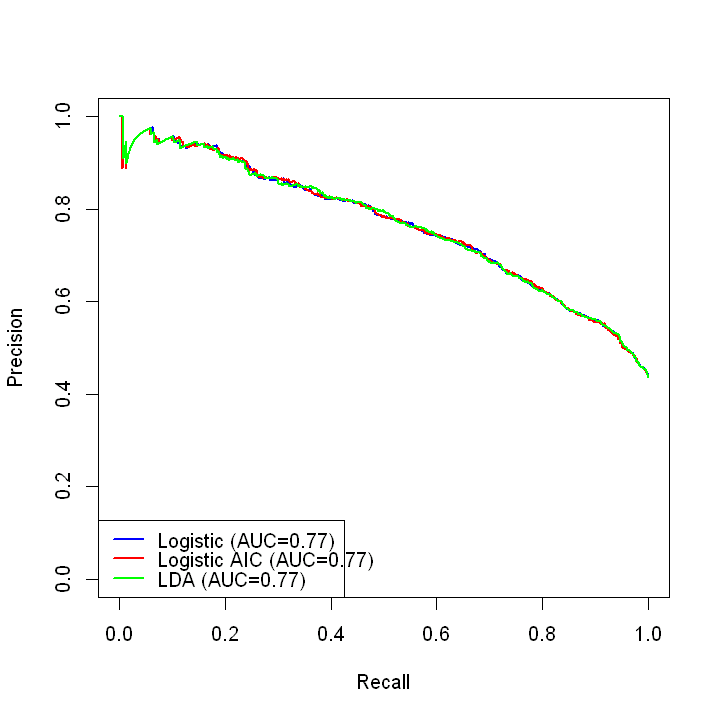

In [40]:
pred.log <- predict(res.log, newdata = test_scaledH, type = "response")
pred.log.aic <- predict(res.log.aic, newdata = test_scaledH, type = "response")
pred.lda <- predict(res.lda, newdata = test_scaledH, type = "response")$posterior[,2]

pr1 = pr.curve(
  scores.class0 = pred.log,
  weights.class0 = y_true,
  curve = TRUE
)

pr2 = pr.curve(
  scores.class0 = pred.log.aic,
  weights.class0 = y_true,
  curve = TRUE
)

pr3 = pr.curve(
  scores.class0 = pred.lda,
  weights.class0 = y_true,
  curve = TRUE
)

plot(pr1$curve[,1], pr1$curve[,2],
     type = "l", col = "blue", lwd = 2,
     xlab = "Recall", ylab = "Precision",
     xlim = c(0,1), ylim = c(0,1))

lines(pr2$curve[,1], pr2$curve[,2], col = "red", lwd = 2)
lines(pr3$curve[,1], pr3$curve[,2], col = "green", lwd = 2)

legend("bottomleft",
       legend = c(
         paste0("Logistic (AUC=", round(pr1$auc.integral,2), ")"),
         paste0("Logistic AIC (AUC=", round(pr2$auc.integral,2), ")"),
        paste0("LDA (AUC=", round(pr3$auc.integral,2), ")")
       ),
       col = c("blue", "red", "green"),
       lwd = 2)

## PLS - DA

In [41]:
library(mdatools)

Warning message:
"package 'mdatools' was built under R version 4.4.3"
Registered S3 methods overwritten by 'mdatools':
  method        from 
  predict.plsda caret
  print.plsda   caret


Attaching package: 'mdatools'


The following object is masked from 'package:caret':

    plsda




In [42]:
X <- model.matrix(Heart_Disease_Risk ~ . , data = train_scaledH)[, -1]
y <- train_scaledH$Heart_Disease_Risk
res.plsda = plsda(X,y, ncomp=10)

Warning message in selectCompNum.pls(model, selcrit = ncomp.selcrit):
"No validation results were found."


In [43]:
summary(res.plsda)


PLS-DA model (class plsda) summary
------------------------------------
Info: 
Number of selected components: 10
Cross-validation: none

Class #1 (0)
    X cumexpvar Y cumexpvar   TP   FP   TN   FN Spec. Sens. Accuracy
Cal       78.66        27.8 5532 1895 3337 1236 0.638 0.817    0.739

Class #2 (1)
    X cumexpvar Y cumexpvar   TP   FP   TN   FN Spec. Sens. Accuracy
Cal       78.66        27.8 3337 1236 5532 1895 0.817 0.638    0.739



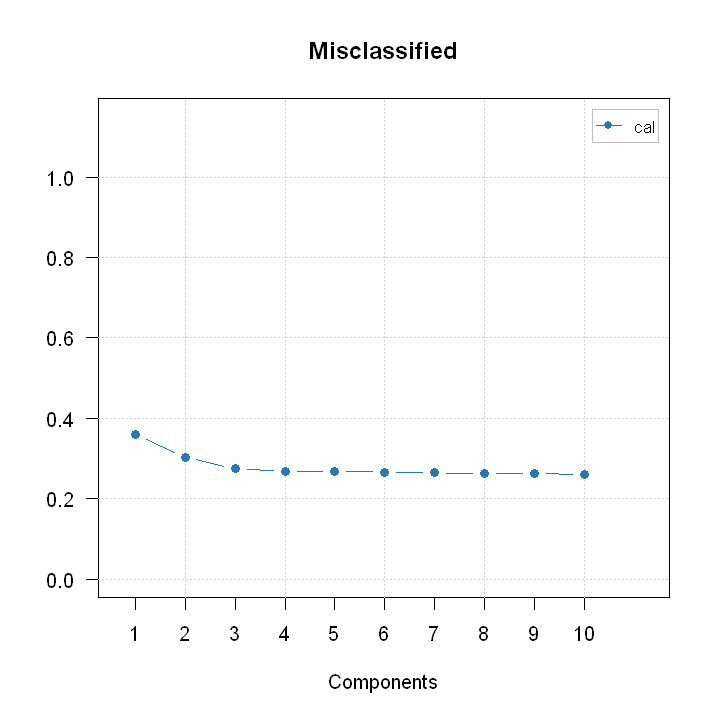

In [44]:
plotMisclassified(res.plsda)

In [45]:
res.plsda$coeffs$p.values[,,2]

NULL

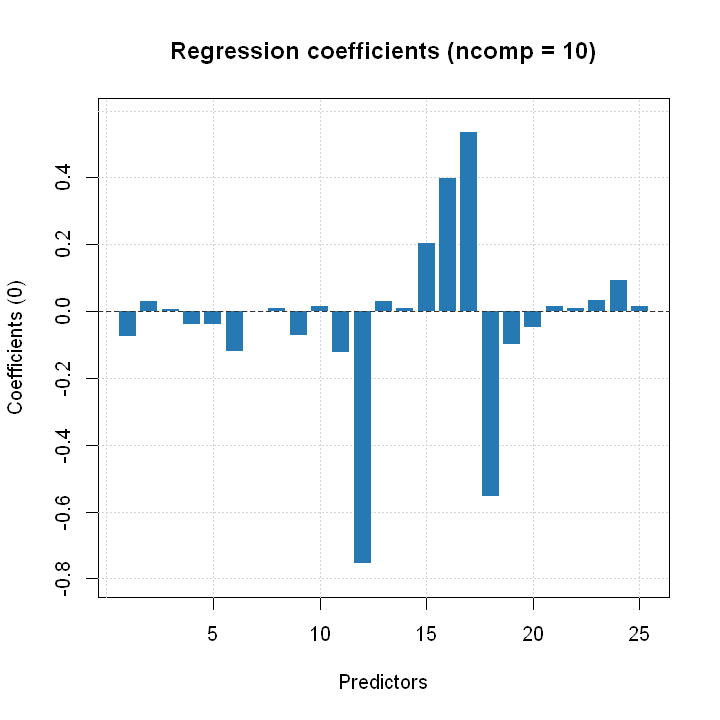

In [46]:
plotRegcoeffs(res.plsda)

In [47]:
pred.plsda = predict(res.plsda,  model.matrix(Heart_Disease_Risk ~ . , data = test_scaledH)[, -1], c.ref=test_scaledH$Heart_Disease_Risk)

In [48]:
table(pred.plsda$c.pred[, 3,2], test_scaledH[, "Heart_Disease_Risk"])

    
        0    1
  -1 1370  518
  1   322  790

In [49]:
sum(pred.plsda$c.pred[, 3,2]==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.plsda$c.pred[, 3,2]==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.plsda$c.pred[, 3,2]==1)

#F beta score
fbeta_score(y_true, pred.plsda$c.pred[, 3,2]==1, beta = 1)

[1] 0.6039755

[1] 0.7104317

[1] 0.6528926

In [50]:
p=-1
score = 0
nc = 1
for (x in seq(-0.6, 0.6, length.out = 50)){
    for (i in 1:10){
        if (score < fbeta_score(y_true, pred.plsda$y.pred[, i,2]>x, beta = 1)){
            p = x
            nc = i
            score = fbeta_score(y_true, pred.plsda$y.pred[, i,2]>x, beta = 1)
        }
    }
}
p
nc
#Recall
sum(pred.plsda$y.pred[, nc,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.plsda$y.pred[, nc,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.plsda$y.pred[, nc,2] >p)

#F beta score
score

table(pred.plsda$y.pred[, nc,2] > p, test_scaledH[, "Heart_Disease_Risk"])

[1] -0.2081633

[1] 9

[1] 0.7652905

[1] 0.6525424

[1] 0.7044335

       
           0    1
  FALSE 1159  307
  TRUE   533 1001

## SVM

In [51]:
library(e1071) #kernel svm
library(LiblineaR) #linear svm

Warning message:
"package 'e1071' was built under R version 4.4.3"

Attaching package: 'e1071'


The following object is masked from 'package:ggplot2':

    element


Warning message:
"package 'LiblineaR' was built under R version 4.4.3"


### Linear SVM

In [52]:
#help(LiblineaR)

In [53]:
# data
x <- as.matrix(subset(train_scaledH, select = -Heart_Disease_Risk))
y <- as.integer(as.character(train_scaledH$Heart_Disease_Risk))

# k-fold split
set.seed(123)
K <- 5
n <- nrow(x)
fold_id <- sample(rep(1:K, length.out = n))

cost_grid <- 2^(-5:5)
weight_grid <- c(1, 2, 3, 5)

results <- expand.grid(cost = cost_grid, w1 = weight_grid)
results$mean_f2 <- NA_real_
results$mean_recall <- NA_real_

for (g in seq_len(nrow(results))) {
  cc <- results$cost[g]
  w1 <- results$w1[g]

  fold_f2 <- numeric(K)
  fold_recall <- numeric(K)

  for (k in 1:K) {
    idx_val <- which(fold_id == k)
    idx_tr  <- which(fold_id != k)

    x_tr <- x[idx_tr, , drop = FALSE]
    y_tr <- y[idx_tr]
    x_val <- x[idx_val, , drop = FALSE]
    y_val <- y[idx_val]

    mod <- LiblineaR(
      data = x_tr,
      target = y_tr,
      type = 2,
      cost = cc,
      wi = c("1" = w1, "0" = 1),
      bias = TRUE,
      verbose = FALSE
    )

    pred <- predict(mod, x_val)$predictions
    pred <- as.integer(pred)

    fold_f2[k] <- fbeta_score(y_val, pred, beta = 1)

    TP <- sum(y_val == 1 & pred == 1)
    FN <- sum(y_val == 1 & pred == 0)
    fold_recall[k] <- if ((TP + FN) == 0) 0 else TP / (TP + FN)
  }

  results$mean_f2[g] <- mean(fold_f2)
  results$mean_recall[g] <- mean(fold_recall)
}

results[order(-results$mean_f2), ][1:10, ]
best <- results[which.max(results$mean_f2), ]
best

,cost,w1,mean_f2,mean_recall
,<dbl>,<dbl>,<dbl>,<dbl>
18,2.00000,2,0.7064006,0.8108228
17,1.00000,2,0.7060578,0.8104243
22,32.00000,2,0.7060578,0.8104243
14,0.12500,2,0.7060011,0.8104243
16,0.50000,2,0.7059992,0.8104243
20,8.00000,2,0.7059955,0.8106199
21,16.00000,2,0.7059955,0.8106199
19,4.00000,2,0.7059411,0.8104243
13,0.06250,2,0.7059386,0.8106199


,cost,w1,mean_f2,mean_recall
,<dbl>,<dbl>,<dbl>,<dbl>
18,2,2,0.7064006,0.8108228


In [54]:
res.svm.lin <- LiblineaR(
      data = x,
      target = y,
      type = 2,
      cost = best$cost,
      wi = c("1" = best$w1, "0" = 1),
      bias = TRUE,
      verbose = FALSE
    )

In [55]:
pred.svm.lin <- predict(res.svm.lin, test_scaledH[,-18])

In [56]:
pred.svm.lin <- predict(res.svm.lin, test_scaledH[,-18])$predictions
table(pred.svm.lin, test_scaledH[, "Heart_Disease_Risk"])
#Recall
sum(pred.svm.lin==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.svm.lin==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.svm.lin==1)

#F beta score
fbeta_score(y_true, pred.svm.lin==1, beta = 1)

            
pred.svm.lin    0    1
           0 1077  266
           1  615 1042

[1] 0.7966361

[1] 0.6288473

[1] 0.7028668

**TODO** kernel SVM, cross validation

### kernel SVM

In [57]:
res.svm.ker = svm(Heart_Disease_Risk ~ ., data = train_scaledH, cost = 1, scale=FALSE)

In [58]:
pred.svm.ker <- predict(res.svm.ker, test_scaledH)
table(pred.svm.ker, test_scaledH[, "Heart_Disease_Risk"])
#Recall
sum(pred.svm.ker==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.svm.ker==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.svm.ker==1)

#F beta score
fbeta_score(y_true, pred.svm.ker==1, beta = 1)

            
pred.svm.ker    0    1
           0 1409  524
           1  283  784

[1] 0.5993884

[1] 0.7347704

[1] 0.6602105

## Random Forest

In [62]:
library(randomForest)

Warning message:
"package 'randomForest' was built under R version 4.4.3"
randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: 'randomForest'


The following object is masked from 'package:dplyr':

    combine


The following object is masked from 'package:ggplot2':

    margin




In [85]:
# TODO : Change the parameter
res.forest = randomForest(Heart_Disease_Risk ~ ., data = train_scaledH,replace = FALSE)

In [86]:
pred.forest <- predict(res.forest, test_scaledH)
table(pred.forest, test_scaledH[, "Heart_Disease_Risk"])
#Recall
sum(pred.forest==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.forest==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.forest==1)

#F beta score
fbeta_score(y_true, pred.forest==1, beta = 2)

           
pred.forest    0    1
          0 1379  527
          1  313  781

[1] 0.5970948

[1] 0.713894

[1] 0.6172937

In [87]:
res.forest$importance

,MeanDecreaseGini
Age,264.78840
Gender,26.57823
Height_cm,251.08865
Weight_kg,267.43228
BMI,266.51537
Systolic_BP,275.91759
Diastolic_BP,224.73959
Cholesterol_Total,251.16449
Cholesterol_LDL,250.87374
Cholesterol_HDL,206.00788


**Comments** For the random forest, the role of physical activity level, family history and stress level decreases.

In [88]:
res.forest$confusion

,0,1,class.error
0,5390,1378,0.2036052
1,1912,3320,0.3654434
